# Fashion MNIST From Scratch

## 1. Import Libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

## 2. Load Dataset

In [2]:
from sklearn.datasets import fetch_openml

fashion_mnist = fetch_openml("Fashion-MNIST", version=1, as_frame=False)

X = fashion_mnist.data
y = fashion_mnist.target.astype(int)

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (70000, 784)
Y Shape: (70000,)


## 3. See the first digit

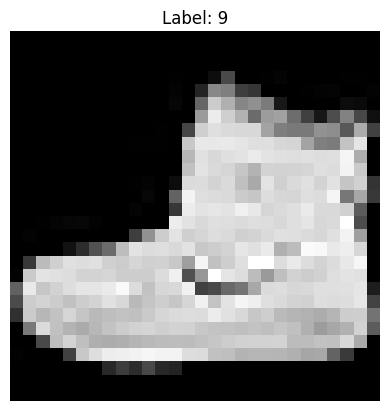

In [3]:
plt.imshow(X[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y[0]}")
plt.axis("off")
plt.show()

## 4. Normalise the data

In [4]:
print("Minimum:", X.min())
print("Maximum:", X.max())
X = X / X.max()
print("Minimum after normalise:", X.min())
print("Minimum after normalise:", X.max())

Minimum: 0
Maximum: 255
Minimum after normalise: 0.0
Minimum after normalise: 1.0


## 5. Build Our First Neuron

### 5.1 Simple Neuron

In [5]:
x = X[0]
w = np.random.randn(784)
b = 0.0
z = np.dot(w, x) + b
print("z =", z)

z = 17.440710659162075


### 5.2 Add ReLU

In [6]:
def relu(z):
    return np.maximum(0, z)
a = relu(z)
print("After Relu:",a)

After Relu: 17.440710659162075


## 6. Make a Layer

In [7]:
weights = np.random.randn(784, 128) * 0.01
biases = np.zeros(128)
z = np.dot(X[:5], weights) + biases
a = relu(z)

print("z shape:", z.shape)
print("a shape:", a.shape)

z shape: (5, 128)
a shape: (5, 128)


## 7. Add Output Layer

### 7.1 Create Output Layer Weight

In [8]:
output_w = np.random.randn(128, 10) * 0.01
output_b = np.zeros(10)
print("w shape:", output_w.shape)

w shape: (128, 10)


### 7.2 Create Output Layer

In [9]:
hidden_a = relu(z)
output_z = np.dot(hidden_a, output_w) + output_b
print("z shape:", output_z.shape)

z shape: (5, 10)


## 8. Softmax

In [10]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z/np.sum(exp_z, axis=1, keepdims=True)
prob = softmax(output_z)
print("Prob Shape:", prob.shape)
print("\nProb values:", prob[0])
print("\nSum of all prob values:", np.sum(prob[0]))

predictions = np.argmax(prob, axis=1)

print("Predictions:", predictions)

Prob Shape: (5, 10)

Prob values: [0.10060591 0.10023519 0.09965152 0.10117192 0.10340111 0.10031714
 0.0977361  0.09826322 0.09758014 0.10103775]

Sum of all prob values: 0.9999999999999999
Predictions: [4 4 4 4 4]


## 9. Cross Entropy Loss

In [11]:
def cross_entropy_loss(prob, y):
    m = y.shape[0]
    
    correct_probability = prob[np.arange(m), y]
    loss = -np.log(correct_probability)
    return np.mean(loss)

loss = cross_entropy_loss(prob, y[:5])

print("Actual labels:", y[:5])
print("Predictions:", predictions)
print("Loss:", loss)

Actual labels: [9 0 0 3 0]
Predictions: [4 4 4 4 4]
Loss: 2.2908136826288086


## 10. Backpropogation

### 10.1 One Hot Labels

In [12]:
y_batch = y[:5]
y_one_hot = np.zeros((5, 10))
y_one_hot[np.arange(5), y_batch] = 1
print("y_one_hot:\n", y_one_hot)

y_one_hot:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### 10.2 Calculate Output gradient

In [13]:
d_output = prob - y_one_hot
print("d_output shape:", d_output.shape)

d_output shape: (5, 10)


## 11. Gradient Output Weights

In [14]:
m = 5
d_output_w = np.dot(hidden_a.T, d_output) / m
d_output_b = np.sum(d_output, axis=0, keepdims=True) / m

print("d_output_w Shape:", d_output_w.shape)
print("d_output_b Shape:", d_output_b.shape)

d_output_w Shape: (128, 10)
d_output_b Shape: (1, 10)


## 12. Update w and b

In [15]:
learning_rate = 0.1
output_w -= learning_rate * d_output_w
output_b -= learning_rate * d_output_b.flatten()

## 13. Backpropogate through

### 13.1 with output layer

In [16]:
d_hidden = np.dot(d_output, output_w.T)  #type:ignore
print("d_hidden shape:", d_hidden.shape)

d_hidden shape: (5, 128)


### 13.2 Relu

In [17]:
d_z_hidden = d_hidden * (z>0)
print("d_z Shape:", d_z_hidden.shape)

d_z Shape: (5, 128)


## 14. Gradient of hidden weights

In [18]:
d_w = np.dot(X[:5].T, d_z_hidden) / 5
d_b = np.sum(d_z_hidden, axis=0, keepdims=True) / 5
print("d_weights Shape:", d_w.shape)
print("d_biases Shape:", d_b.shape)

d_weights Shape: (784, 128)
d_biases Shape: (1, 128)


## 15. Update the hidden layer

In [19]:
weights -= learning_rate * d_w
biases -= learning_rate * d_b.flatten()

## 16. Training Loop

### 16.1 Train/Test Data

In [20]:
X_train = X[:60000]
X_test = X[60000:]
y_train = y[:60000]
y_test = y[60000:]

### 16.2 Reinitialise Network

In [21]:
np.random.seed(42)

w = np.random.randn(784, 128) * 0.01
b = np.zeros(128)

output_w = np.random.randn(128, 10) * 0.01
output_b = np.zeros(10)

### 16.3 Set Traing Parameter

In [22]:
learning_rate = 0.1
batch_size = 64
epochs = 10

### 16.4 Loop

In [23]:
for epoch in range(epochs):
    # Suffle training data
    indices = np.random.permutation(len(X_train))
    X_train = X_train[indices]
    y_train = y_train[indices]
    
    for start in range(0, len(X_train), batch_size):
        end = start + batch_size
        X_batch = X_train[start:end]
        y_batch = y_train[start:end]
        
        # Forward Pass
        z_hidden = np.dot(X_batch, w) + b
        hidden_output = relu(z_hidden)
        
        z_output = np.dot(hidden_output, output_w) + output_b
        prob = softmax(z_output)
        
        # Loss
        loss = cross_entropy_loss(prob, y_batch)
        
        # Backpropogation
        m = len(X_batch)
        
        ## Output Gradient
        y_one_hot = np.zeros((m, 10))
        y_one_hot[np.arange(m), y_batch] = 1
        
        d_output = prob - y_one_hot
        
        ## Output layer gradient
        d_output_w = np.dot(hidden_output.T, d_output) / m
        d_output_b = np.sum(d_output, axis=0, keepdims=True) / m
        
        ## Hidden layer gradient
        d_hidden = np.dot(d_output, output_w.T)
        
        ## Relu gradient
        d_z_hidden = d_hidden * (z_hidden > 0)
        
        ## Hidden layer gradient
        d_w = np.dot(X_batch.T, d_z_hidden) / m
        d_b = np.sum(d_z_hidden, axis=0, keepdims=True) / m
        
        # Update Weights
        w -= learning_rate * d_w
        b -= learning_rate * d_b.flatten()
        
        output_w -= learning_rate * d_output_w 
        output_b -= learning_rate * d_output_b.flatten()
        
    print(
        f"Epoch {epoch + 1}/{epochs},"
        f"Loss: {loss:.4f}"
    )

Epoch 1/10,Loss: 0.5180
Epoch 2/10,Loss: 0.6233
Epoch 3/10,Loss: 0.3544
Epoch 4/10,Loss: 0.5061
Epoch 5/10,Loss: 0.3384
Epoch 6/10,Loss: 0.2889
Epoch 7/10,Loss: 0.4017
Epoch 8/10,Loss: 0.2398
Epoch 9/10,Loss: 0.3506
Epoch 10/10,Loss: 0.3994


## 17. Test the network

In [24]:
z_hidden_test = np.dot(X_test, w) + b    #type:ignore
hidden_test = relu(z_hidden_test)

z_output_test = np.dot(hidden_test, output_w) + output_b    #type:ignore
prob_test = softmax(z_output_test)

prediction_test = np.argmax(prob_test, axis=1)
accuracy = np.mean(prediction_test == y_test)
print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

Test Accuracy: 0.8698
Test Accuracy (%): 86.98


## 18. Visualize Predictions

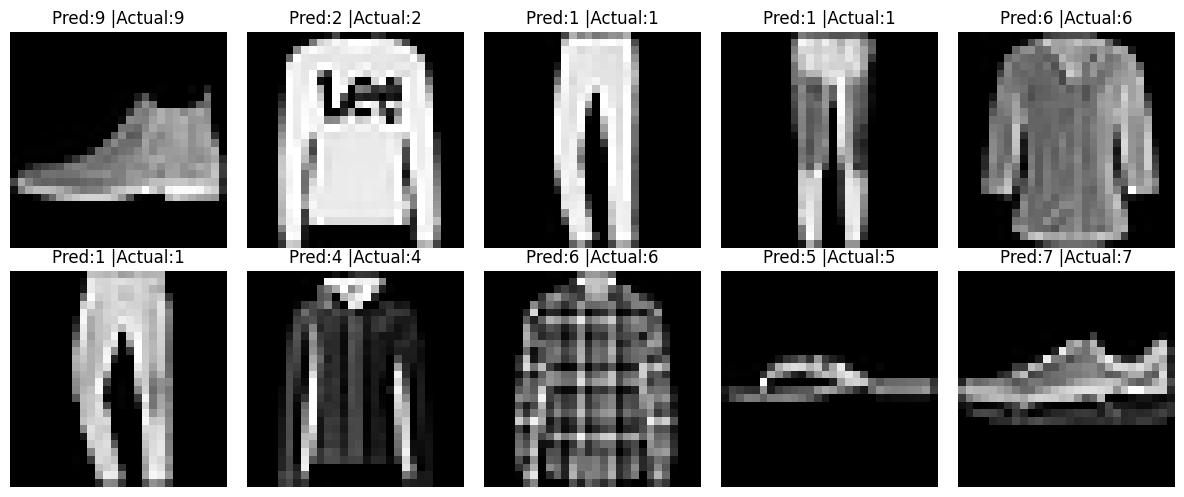

In [25]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred:{prediction_test[i]} |"
                 f"Actual:{y_test[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()